In [ ]:
!pip install pandas openpyxl xlrd

In [ ]:
import pandas as pd 

In [ ]:
data = pd.read_excel("C:/Users/mocim/OneDrive/Desktop/Lessons/Week 2/Project/raw_data_shark_attacks.xls")

In [ ]:
df = data[["Country", "Activity", "Location", "Sex", "Fatal Y/N", "Species ", "Type"]]

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.shape

(7097, 7)

In [ ]:
df.tail()

,Country,Activity,Location,Sex,Fatal Y/N,Species,Type
7092,AUSTRALIA,Diving,Roebuck Bay,M,Y,NaN,Unprovoked
7093,AUSTRALIA,Pearl diving,NaN,M,Y,NaN,Unprovoked
7094,USA,Swimming,Ocracoke Inlet,M,Y,NaN,Unprovoked
7095,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",M,Y,NaN,Unprovoked
7096,CEYLON (SRI LANKA),Swimming,"Below the English fort, Trincomalee",M,Y,NaN,Unprovoked


In [ ]:
df.isna().sum()/len(df) *100

Country       0.704523
Activity      0.000000
Location      7.989291
Sex           0.000000
Fatal Y/N     0.000000
Species      44.117233
Type          0.253628
dtype: float64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7097 entries, 0 to 7096
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    7047 non-null   object
 1   Activity   7097 non-null   object
 2   Location   6530 non-null   object
 3   Sex        7097 non-null   object
 4   Fatal Y/N  7097 non-null   object
 5   Species    3966 non-null   object
 6   Type       7079 non-null   object
dtypes: object(7)
memory usage: 388.2+ KB


- Replace null values for Unknown for Activity, Sex and Fatal Y/N as they are around 8%

In [ ]:
df[["Activity", "Sex", "Fatal Y/N"]] = df[["Activity", "Sex", "Fatal Y/N"]].fillna("Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\3811356152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["Activity", "Sex", "Fatal Y/N"]] = df[["Activity", "Sex", "Fatal Y/N"]].fillna("Unknown")


- Check duplicates

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(325)

In [ ]:
df["Sex"].value_counts()

Sex
M          5697
F           814
Unknown     586
Name: count, dtype: int64

- Check inconsistent values

In [ ]:
df ["Sex"] = df ["Sex"].str.strip()

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\3234921729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].str.strip()


In [ ]:
df ["Sex"] = df ["Sex"].str.upper()

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\3511102203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].str.upper()


In [ ]:
df ["Sex"] = df ["Sex"].replace (["?", "UNKNOWN", "N", "M F", "LLI", ".", "M X 2"], "Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\2089057638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].replace (["?", "UNKNOWN", "N", "M F", "LLI", ".", "M X 2"], "Unknown")


In [ ]:
df["Activity"].nunique()

1614

In [ ]:
df["Activity"].value_counts().head(30)

Activity
Swimming related    1770
Surfing related     1609
Fishing related     1272
Other               1015
Diving related       702
unknown              586
Boating related      143
Name: count, dtype: int64

In [ ]:
df["Activity"].value_counts().info()

<class 'pandas.core.series.Series'>
Index: 7 entries, Swimming related to Boating related
Series name: count
Non-Null Count  Dtype
--------------  -----
7 non-null      int64
dtypes: int64(1)
memory usage: 112.0+ bytes


In [ ]:
df["Activity"] = df["Activity"].str.strip().str.lower()

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\3029557794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = df["Activity"].str.strip().str.lower()


In [ ]:
df["Activity"].isna().sum()

np.int64(0)

In [ ]:
df.loc[df["Activity"].str.contains("surf|Boarding|boarding"), "Activity"] = "Surfing related"
df.loc[df["Activity"].str.contains("fishing"), "Activity"] = "Fishing related"
df.loc[df["Activity"].str.contains("swim"), "Activity"] = "Swimming related"
df.loc[df["Activity"].str.contains("diving"), "Activity"] = "Diving related"
df.loc[df["Activity"] == "Boarding related", "Activity"] = "Surfing related"
df.loc[df["Activity"].str.contains ("walking|playing"), "Activity"] = "Non water activities"

df.loc [df["Activity"] == "Non water activities", "Activity"] = "Other"  # Changed my mind, want them 2 in Others 
df.loc [df["Activity"] == "sea disaster", "Activity"] = "Other"

In [ ]:
df.loc [ df["Activity"].str.contains ("kayaking|canoeing|rowing|maybe fell overboard|fell overboard"), "Activity" ] = "Boating related"

In [ ]:
df.loc[ df["Activity"].isin(["wading", "bathing", "standing", "treading water", "floating"]), "Activity"] = "Swimming related"
df.loc [ df["Activity"].isin( ["snorkeling"]), "Activity" ] = "Diving related" 

In [ ]:
activity_counts = df["Activity"].value_counts()

rare_activities = activity_counts [activity_counts < 10].index
df.loc[df["Activity"].isin(rare_activities), "Activity"] = "Other"

In [ ]:
df["Activity"].value_counts().head(20)

Activity
Swimming related    1770
Surfing related     1609
Fishing related     1272
Other               1015
Diving related       702
unknown              586
Boating related      143
Name: count, dtype: int64

In [ ]:
df["Fatal Y/N"].isna().sum()

np.int64(0)

In [ ]:
df["Fatal Y/N"].value_counts()

Fatal Y/N
No         4959
Yes        1495
Unknown     643
Name: count, dtype: int64

In [ ]:
df["Fatal Y/N"] = df["Fatal Y/N"].str.upper().str.strip()

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\3861697453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].str.upper().str.strip()


In [ ]:
df["Fatal Y/N"] = df["Fatal Y/N"].replace({"N": "No","Y": "Yes", "UNKNOWN": "Unknown"})

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\2764064334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].replace({"N": "No","Y": "Yes", "UNKNOWN": "Unknown"})


In [ ]:
df["Fatal Y/N"].isna().sum()

np.int64(1)

In [ ]:
df["Fatal Y/N"] = df["Fatal Y/N"].fillna ("Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_9620\2170484850.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].fillna ("Unknown")


In [ ]:
df.loc[ df["Fatal Y/N"].str.contains("F|M|NQ|Y X 2"), "Fatal Y/N"] = "Unknown"

In [ ]:
df

,Country,Activity,Location,Sex,Fatal Y/N,Species,Type
0,Australia,Fishing related,Michaelmas Island King George Sound,M,Yes,Great White shark 4.5 m,Unprovoked
1,Brazil,Swimming related,Boa Via gem beach,F,No,Tiger shark 3m,Unprovoked
2,Brazil,Swimming related,PierrebBeach,M,No,Bull shark,Unprovoked
3,Australia,Surfing related,Red Cliff beach Yuraygir National Park,M,No,Bull shark,Unprovoked
4,USA,Surfing related,Cromwell's beach Oahu,M,No,2.4m (8ft) shark,Unprovoked
...,...,...,...,...,...,...,...
7092,AUSTRALIA,Diving related,Roebuck Bay,M,Yes,NaN,Unprovoked
7093,AUSTRALIA,Diving related,NaN,M,Yes,NaN,Unprovoked
7094,USA,Swimming related,Ocracoke Inlet,M,Yes,NaN,Unprovoked
7095,PANAMA,unknown,"Panama Bay 8ºN, 79ºW",M,Yes,NaN,Unprovoked


In [ ]:
df.to_csv("shark_clean.csv", index=False)  #copy 

### Hypothesis

In [ ]:
df.groupby("Activity")["Fatal Y/N"].value_counts()

Activity          Fatal Y/N
Boating related   No             85
                  Yes            49
                  Unknown         9
Diving related    No            485
                  Yes           147
                  Unknown        70
Fishing related   No           1010
                  Yes           181
                  Unknown        81
Other             No            561
                  Yes           347
                  Unknown       107
Surfing related   No           1432
                  Yes           116
                  Unknown        61
Swimming related  No           1075
                  Yes           546
                  Unknown       149
unknown           No            311
                  Unknown       166
                  Yes           109
Name: count, dtype: int64

In [ ]:
df_fatal["Fatal Y/N"].value_counts()

Fatal Y/N
No     4959
Yes    1495
Name: count, dtype: int64

In [ ]:
pd.crosstab(df["Activity"], df["Fatal Y/N"])

df_fatal = df[df["Fatal Y/N"] != "Unknown"]  # Exclude Unknown from rows. But here does nothing because the row is "unknown" lowercase. 


In [ ]:
df_fatal = fatal_rate.drop ("unknown")  # Remove unknown rows 

In [ ]:
fatal_rate.index

Index(['Boating related', 'Diving related', 'Fishing related', 'Other',
       'Surfing related', 'Swimming related', 'unknown'],
      dtype='object', name='Activity')

In [ ]:
type (df_fatal)

pandas.core.frame.DataFrame

In [ ]:
# Remove unknown rows from activity 
df_fatal2 = df[df["Activity"] != "unknown"]


In [ ]:
df_fatal2["Activity"].value_counts()

Activity
Swimming related    1770
Surfing related     1609
Fishing related     1272
Other               1015
Diving related       702
Boating related      143
Name: count, dtype: int64

In [ ]:
fatal_rate = (pd.crosstab(df_fatal2["Activity"], df_fatal["Fatal Y/N"], normalize="index") * 100).round (2)

fatal_rate

Fatal Y/N,No,Yes
Activity,,
Boating related,63.43,36.57
Diving related,76.74,23.26
Fishing related,84.80,15.20
Other,61.78,38.22
Surfing related,92.51,7.49
Swimming related,66.32,33.68


<Axes: xlabel='Activity'>

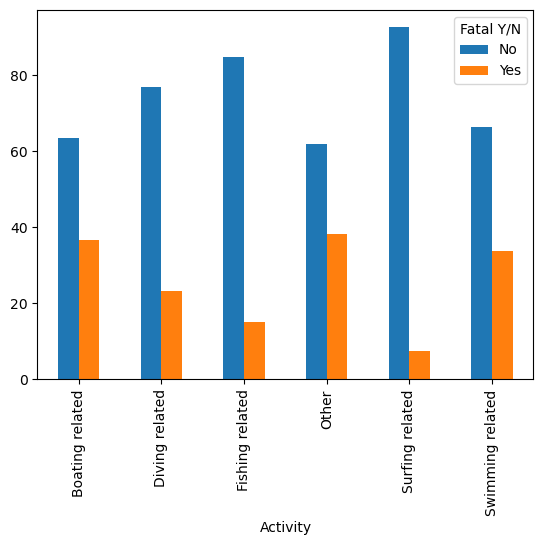

In [ ]:
fatal_rate.plot (kind ="bar")

Among the recorded shark attacks swimming, surfing and fishing related activities are the most frequent in the dataset. 
Boating related act has the highest fatal rate, followed by swimming. 

The highest non fatal rate is related to surfing related, followed by fishing and diving. 


- Gender - activity
- gender - fatal 

In [ ]:
gender_fatal ["Sex"].value_counts()

Sex
M    5697
F     814
Name: count, dtype: int64

In [ ]:
gender_fatal = df [df["Sex"] != "Unknown" ]

In [ ]:
gender_fatal_rate = (pd.crosstab (gender_fatal ["Sex"], df_fatal ["Fatal Y/N"], normalize = "index")*100).round (2)
gender_fatal_rate

Fatal Y/N,No,Yes
Sex,,
F,83.20,16.80
M,75.94,24.06


<Axes: xlabel='Sex'>

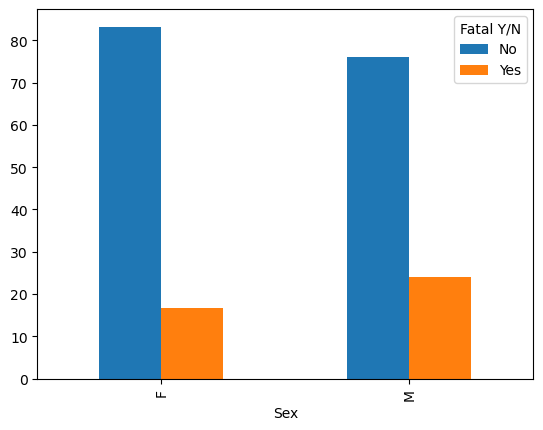

In [ ]:
gender_fatal_rate.plot (kind = "bar")

Male and female had the around the same number of shark attacks recorded. 
Fatal rates are slightly higher in males than females, and non fatal rates slightly lower than female. 


In [ ]:
df ["Activity"].value_counts()

Activity
Swimming related    1770
Surfing related     1609
Fishing related     1272
Other               1015
Diving related       702
unknown              586
Boating related      143
Name: count, dtype: int64

In [ ]:
sex_activity_rate = (pd.crosstab (df_fatal2["Activity"], gender_fatal ["Sex"], normalize = "index")*100).round (2)
sex_activity_rate

Sex,F,M
Activity,,
Boating related,11.11,88.89
Diving related,14.18,85.82
Fishing related,2.28,97.72
Other,12.59,87.41
Surfing related,8.37,91.63
Swimming related,21.63,78.37


In [ ]:
gender_fatal ["Sex"].value_counts()

Sex
M    5697
F     814
Name: count, dtype: int64

<Axes: xlabel='Activity'>

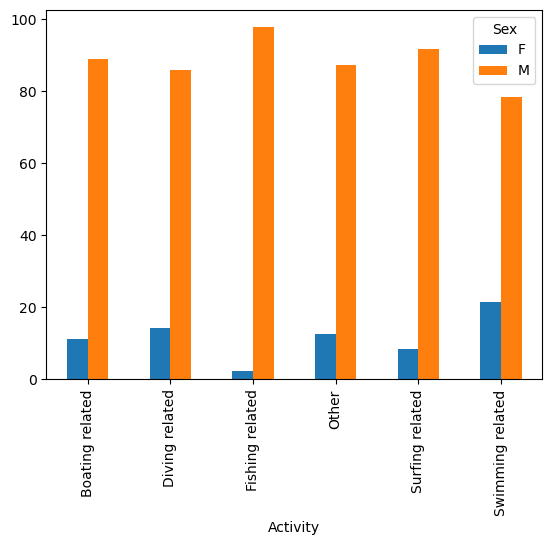

In [ ]:
sex_activity_rate.plot (kind = "bar")

# Not meaningful as males registries are significantly higher than females. 